<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Image_data_preprocessing_VII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image data preprocessing VII**

## **Context**

In this notebook, we will explore some fundamental image processing techniques in computer vision, specifically focusing on

*   **Template Matching:** A method for finding small parts of an input image that match a predefined template image.
*   **Corner Detection:** Techniques used to identify significant points in an image where intensity changes across multiple directions. This section covers two popular methods:
    *   **Harris Corner Detection (HCD):** Analyzes intensity changes to identify corners.
    *   **Shi-Tomasi Corner Detection (STCD):** Detects strong corners based on the Shi-Tomasi criterion.

## **Template matching**

Template matching is a technique in image processing used to find portions of an input image (a larger image or target image) that matches a template image (reference image or smaller image). Template Matching is commonly used for object detection, image recognition, and pattern recognition tasks. It is the simplest technique to perform these tasks and may have limitations.

In template matching, parts of an input image are compared with a predefined template (a reference image) to identify or locate the areas in the input image that correspond to the template. This method works by sliding the template image over the input image and calculating similarity metric for every position to find the best match.

**Initial setup**

In [1]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

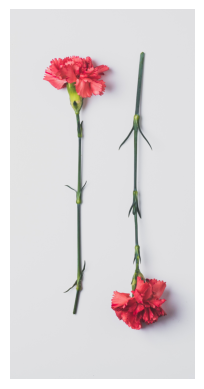

In [5]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/bunga_kembar.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img)
plt.show()

In [6]:
# Image dimension
input_img.shape

(4000, 2000, 3)

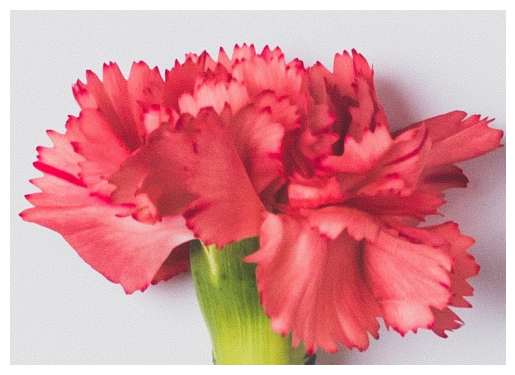

In [7]:
# Attaching the template image

# Image link
url1 = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/template_bunga.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url1) as f:
    template_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
template_img = np.array(template_img)

# Displaying the template image
plt.axis('off')
plt.imshow(template_img)
plt.show()

In [8]:
# Image dimension
template_img.shape

(524, 732, 3)

We can see that the template size (524x732 pixels) is smaller than the input image (4000 x 2000 pixels).

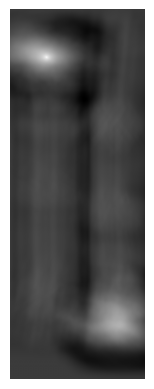

In [9]:
# Matching the image based on template
img_metric= cv2.matchTemplate(input_img,
                               template_img,
                              cv2.TM_CCOEFF)

plt.axis('off')
plt.imshow(img_metric, cmap='gray')
plt.show()

In [10]:
# Find the maximum pixel coordinates
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(img_metric)
print(max_loc)

(344, 453)


Now we add a bounding box for marking the matched template.

In [12]:
# Check the image template sizes
height, width, _ = template_img.shape
print('height:', height)
print('Width:', width)

height: 524
Width: 732


In [13]:
# Setting the bounding box based on the template sizes
left_top = max_loc
right_down = (left_top[0]+width, left_top[1]+height)
print(left_top, right_down)

(344, 453) (1076, 977)


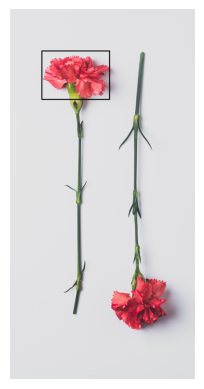

In [17]:
img_input2 = input_img.copy()

# Add the bounding box
cv2.rectangle(img_input2,
             left_top,
             right_down,
             color=(0,0,0),
             thickness=10)
plt.axis('off')
plt.imshow(img_input2, cmap='gray')
plt.show()

We can see that even there are two flowers, only one flower that can be detected. This can be explained as the template matching method only detects the flower object that identical (exactly alike/similar) with the template image.

## **Corner detection**

Corner detection is a key technique in computer vision used to identify important points in an image where there is a significant change in intensity across multiple directions. These corners are important for tasks like feature matching, motion tracking and image stitching.

In this tutorial, we will learn two corner detection methods, Harris corner detection (HCD) and Shi-Thomas corner detection (STCD).

### **HCD method**

Harris corner detection (HCD) is a key technique in computer vision for detecting corners in images. It works by analyzing how the intensity of the image changes in different directions, helping us identify areas with significant variations which are considered corners. The core of the Harris Corner Detection is handled by the OpenCV function `cv2.cornerHarris()`.

In [12]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

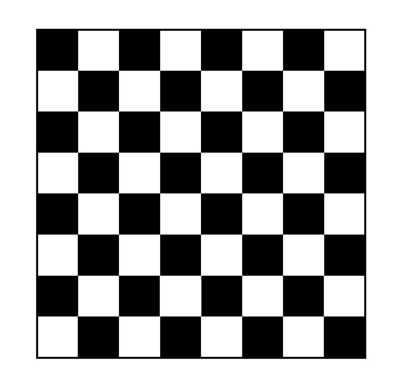

In [13]:
# Attaching the input image

# Image link
url2 = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/chess_corner.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url2) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img,  cmap='gray')
plt.show()

Preprocessing to grayscale color is conducted before implementing the `cv2.cornerHarris()` function

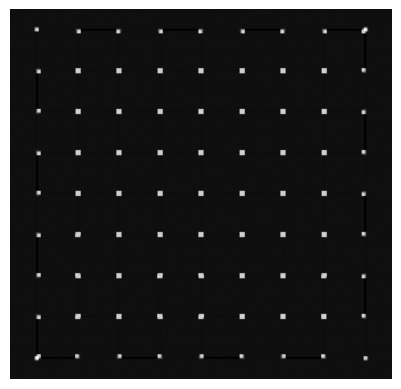

In [14]:
# Setting HCD parameters
winSize = 7
ksize = 3
k = 0.04
filter7x7 = np.ones(shape=(7,7))

# Converting input_img to grayscale
gray_input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)

# Applying the HCD algorithm
img_signature = cv2.cornerHarris(gray_input_img,    # Input image
                                winSize,            # Window size
                                ksize,              # Sobel filter size
                                k)                  # HCD factor

img_signature = cv2.dilate(img_signature, kernel=filter7x7)


# Displaying the image
plt.axis('off')
plt.imshow(img_signature, cmap='gray')
plt.show()

The code  instructs to change the color of the pixels in the input image to a dark color where the pixels have been identified as corners by HCD method.

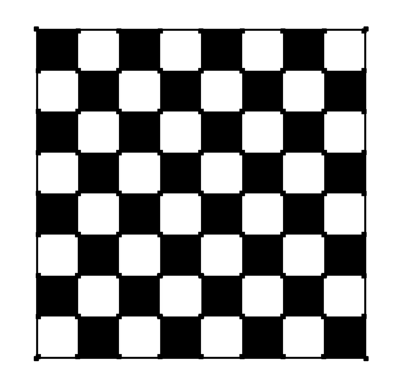

In [15]:
# Changing pixel color
input_img[img_signature > 0.01 * img_signature.max()] = 0
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

Now, lets apply the HCD method to the image of building.

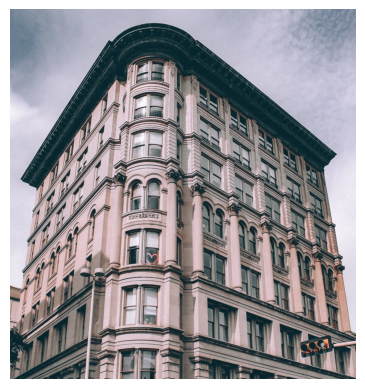

In [17]:
# Attaching the input image

# Image link
url3 = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/building_corner.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url3) as f:
    building_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
building_img = np.array(building_img)

# Displaying the original image
plt.axis('off')
plt.imshow(building_img,  cmap='gray')
plt.show()

In the building image above, we can edit the input image and change the pixel intensity at the detected corner to white (instead of black) to increase its visibility in the input image.

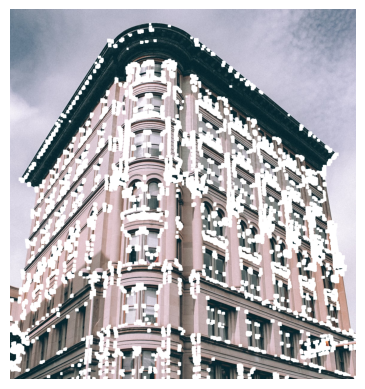

In [20]:
# Setting HCD parameters
winSize = 7
ksize = 3
k = 0.04
kernel_sobel = np.ones(shape=(7,7))

# Converting building_img to grayscale
gray_building_img = cv2.cvtColor(building_img, cv2.COLOR_BGR2GRAY)

# Applying the HCD algorithm
img_signature = cv2.cornerHarris(gray_building_img, winSize, ksize, k)

img_signature = cv2.dilate(img_signature, kernel=kernel_sobel)

building_img[img_signature > 0.01*img_signature.max()] = 255
plt.axis('off')
plt.imshow(building_img, cmap='gray')
plt.show()

We have the image above as the result of HCD method.

### **STCD method**

Shi-Thomas Corner Detector (STCD) method works by scanning small regions of an image, identifying areas where the intensity changes noticeably in all directions.

We will use the same input image from previous experiment for this study.

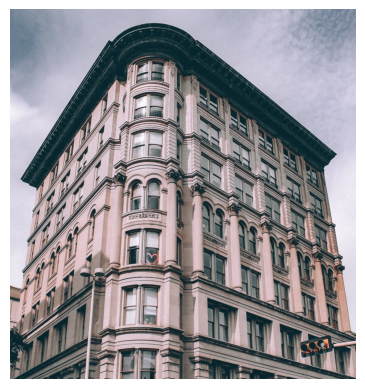

In [21]:
# Attaching the input image

# Image link
url3 = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/building_corner.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url3) as f:
    building_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
building_img = np.array(building_img)

# Displaying the original image
plt.axis('off')
plt.imshow(building_img,  cmap='gray')
plt.show()

Again, we conduct image preprocessing to grayscale, before STCD implementation.

In [ ]:
# Converting building_img to grayscale
gray_building_img = cv2.cvtColor(building_img, cv2.COLOR_BGR2GRAY)

We can make experiment with STCD parameters below. In this case we want to try to find 50 important corners (`maxcorners` = 50) on the building image.

In [22]:
# Setting STCD parameters
maxCorners = 50
qualityLevels = 0.01
minDistance = 10

The OpenCV function `cv2.goodFeaturesToTrack()` helps us implement the Shi-Tomasi method for corner detection. This function detects the strongest corners in an image based on the Shi-Tomasi criterion.

In [24]:
# Explore the corners
corners = cv2.goodFeaturesToTrack(gray_building_img,   # Input image
                                 maxCorners,      # Total corners
                                 qualityLevels,   # Limit of quality
                                 minDistance)     # Detection distance


# Print 5 examples (the location of the corners)
corners = np.int16(corners)
print(corners[:5])

[[[1089  722]]

 [[ 455  326]]

 [[1113  829]]

 [[1120  861]]

 [[ 461  210]]]


Unlike HCD which stores corner detection results in the form of a grayscale image (image signature), STCD stores corner detection results as a list of corner point coordinates. To visualize the detection results on the input image, a small circle (red color) is added to the input image with the detected corner point as its center.

In [25]:
for c in corners:                   # Looping operation for edge point coordinates
    x,y = c.ravel()                 # Converting into 1D array
    cv2.circle(img=building_img,    # Drawing a circle on the detected coordinates
              center=(x,y),
              radius=10,
              color=255,
              thickness=-1)

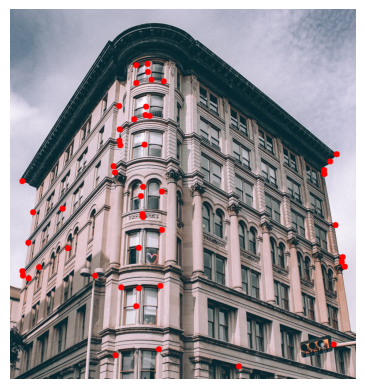

In [26]:
# Displaying the processed image
plt.axis('off')
plt.imshow(building_img, cmap='gray')
plt.show()

Now, we have implemented the STCD method to the input image.

## **Conclusion**

In this tutorial, We have implemented some image processing techniques such as


*   **Template Matching:** WE demonstrated how to locate a specific template within a larger image, identifying areas of high similarity. This technique is useful for object detection and pattern recognition where the target object's appearance is known.
*   **Harris Corner Detection (HCD):** We implemented a method to identify corners in an image by analyzing intensity changes in multiple directions. We applied HCD to highlight corners, which are robust features often used in image registration and tracking.
*   **Shi-Tomasi Corner Detection (STCD):** We explored another effective corner detection algorithm that identifies 'good features to track'. STCD provides a list of corner coordinates, which are valuable for feature tracking and camera calibration tasks due to their stability.